In [1]:
!pip install langchain_community langchain_google_genai langchain-chroma>=0.1.2 pypdf

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
google-generativeai 0.8.5 requires google-ai-generativelanguage==0.6.15, but you have google-ai-generativelanguage 0.9.0 which is incompatible.
opentelemetry-exporter-otlp-proto-http 1.37.0 requires opentelemetry-exporter-otlp-proto-common==1.37.0, but you have opentelemetry-exporter-otlp-proto-common 1.38.0 which is incompatible.
opentelemetry-exporter-otlp-proto-http 1.37.0 requires opentelemetry-proto==1.37.0, but you have opentelemetry-proto 1.38.0 which is incompatible.
opentelemetry-exporter-otlp-proto-http 1.37.0 requires opentelemetry-sdk~=1.37.0, but you have opentelemetry-sdk 1.38.0 which is incompatible.
google-adk 1.19.0 requires opentelemetry-api<=1.37.0,>=1.37.0, but you have opentelemetry-api 1.38.0 whi

### **Librerías**

In [1]:
import os
import getpass
from IPython.display import Markdown, display
from collections.abc import KeysView

#Langchain mensajes
from langchain_core.messages import AIMessage, SystemMessage, HumanMessage

#Langchain prompts
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.prompt_values import ChatPromptValue

#Langchain cadena
from langchain_core.runnables import chain
from langchain_core.runnables.base import RunnableSequence

#Langchain chat model (Google)
from langchain_google_genai import ChatGoogleGenerativeAI

#Langchain document loaders
from langchain_core.documents.base import Document
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.document_loaders.csv_loader import CSVLoader

#Langchain text splitters
from langchain_text_splitters import CharacterTextSplitter
from langchain_text_splitters import RecursiveCharacterTextSplitter
import tiktoken
from tiktoken.core import Encoding

#Langchain embedding model (Google)
from langchain_google_genai import GoogleGenerativeAIEmbeddings

#Langchain vector store (Chroma)
from langchain_chroma import Chroma
from langchain_core.vectorstores.base import VectorStoreRetriever

C:\Users\Nitvn\AppData\Local\Temp\ipykernel_21432\4185154703.py:22: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
from dotenv import load_dotenv

# Load the .env file
load_dotenv()

google_api_key = os.getenv("GOOGLE_API_KEY")

In [ ]:
# Ingresa el API key
# os.environ["GOOGLE_API_KEY"]: str = getpass.getpass("Ingresa tu Google AI API key: ")

Ingresa tu Google AI API key: ··········


### **Document Loaders**

Se listan ejemplos para los principales:

*   WebBaseLoader
*   PyPDFLoader
*   CSVLoader

La lista completa de document loaders puede ser encontrada en la documentación: https://python.langchain.com/docs/integrations/document_loaders/

#### **WebBaseLoader**

In [6]:
#WebBaseLoader carga información de la web y transforma el código html en documentos - requiere la dirección de la página web
loader: WebBaseLoader = WebBaseLoader("https://www.diccionariodedudas.com/reglas-ortograficas/")

#Luego de instanciar la clase, se pueden cargar los documentos con el método load
documento_web: list = loader.load()

In [7]:
documento_web

[Document(metadata={'source': 'https://www.diccionariodedudas.com/reglas-ortograficas/', 'title': 'Principales reglas ortográficas del español - Diccionario de Dudas', 'description': 'Las reglas ortográficas son las normas que se aplican en la escritura (como, por ejemplo, saber cuándo poner una tilde). El uso correcto de las reglas nos...', 'language': 'es'}, page_content='\n\n\n\nPrincipales reglas ortográficas del español - Diccionario de Dudas\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n \n\n\n \n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nPalabras Homófonas\nPalabras Parónimas\nFonética y fonología\nUso\nGrafía\nLéxicas\n\nVer más\n\nLatinismos\nExtranjerismos\nBarbarismos\nUltracorrecciones\n\n\n\n\n\n\n\n\nOrtografía \nPrincipales reglas ortográficas del español\n\n\n\n\n\n\nTomás Muriel\n\nFilólogo y profesor de español\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n \n\n\n\n\nLas reglas ortográficas son las normas que se aplican en la escritura (como, por ejemplo, saber cuándo poner una tilde). El uso c

In [8]:
#Podemos ver que los documentos cuentan con los siguientes atributos: id, metadata, page_content y type
contenido_loader: KeysView[str] = documento_web[0].__dict__.keys()

for contenido in contenido_loader:
    print(contenido)

id
metadata
page_content
type


In [9]:
#Los documentos son de clase "Document", podemos acceder a los atributos de cada documento de la siguiente manera:
documento_web_cargado_0: Document = documento_web[0]

documento_web_metadata: dict = documento_web_cargado_0.metadata
documento_web_contenido: str = documento_web_cargado_0.page_content
documento_web_tipo: str = documento_web_cargado_0.type

print(documento_web_metadata)
#print(documento_web_contenido)
#print(documento_web_tipo)

{'source': 'https://www.diccionariodedudas.com/reglas-ortograficas/', 'title': 'Principales reglas ortográficas del español - Diccionario de Dudas', 'description': 'Las reglas ortográficas son las normas que se aplican en la escritura (como, por ejemplo, saber cuándo poner una tilde). El uso correcto de las reglas nos...', 'language': 'es'}


#### **PyPDFLoader**

In [16]:
import os

root_path = os.getcwd()

print(root_path)

c:\Users\Nitvn\Documentos\Dev\generative-ai-tools\langchain-llamaindex


In [17]:
#El pdf loader ayuda a convertir la información presente en un pdf a un documento - requiere la ruta del pdf que se desea cargar

ruta_archivo_pdf: str = root_path + "/RAG Data/La_cultura_del_Perú.pdf"
print(ruta_archivo_pdf)
#La clase "PyPDFLoader" se instancia con la ruta del archivo pdf
loader: PyPDFLoader = PyPDFLoader(ruta_archivo_pdf)

#Al igual que en el previo loader, se pueden cargar los documentos con el método load
documento_pdf: list = loader.load()

c:\Users\Nitvn\Documentos\Dev\generative-ai-tools\langchain-llamaindex/RAG Data/La_cultura_del_Perú.pdf


In [18]:
#Podemos ver que los documentos cuentan con los siguientes atributos: id, metadata, page_content y type
contenido_loader: KeysView[str] = documento_pdf[0].__dict__.keys()

for contenido in contenido_loader:
    print(contenido)

id
metadata
page_content
type


In [19]:
#Los documentos son de clase "Document", podemos acceder a los atributos de cada documento de la siguiente manera:
documento_pdf_cargado_0: Document = documento_pdf[0]

documento_pdf_metadata: dict = documento_pdf_cargado_0.metadata
documento_pdf_contenido: str = documento_pdf_cargado_0.page_content
documento_pdf_tipo: str = documento_pdf_cargado_0.type

print(documento_pdf_metadata)
#print(documento_pdf_contenido)
#print(documento_pdf_tipo)

{'producer': 'Adobe PDF library 15.00', 'creator': 'Adobe Illustrator CC 22.0 (Windows)', 'creationdate': '2020-08-07T18:05:47-05:00', 'title': 'La cultura del Perú', 'moddate': '2020-08-07T18:15:05-05:00', 'source': 'c:\\Users\\Nitvn\\Documentos\\Dev\\generative-ai-tools\\langchain-llamaindex/RAG Data/La_cultura_del_Perú.pdf', 'total_pages': 3, 'page': 0, 'page_label': '1'}


#### **CSVLoader**

In [20]:
#El loader para csv requiere la ruta del archivo y también es posible pasarle la siguiente información

ruta_archivo_csv: str = root_path + "/RAG Data/Información empleados.csv"

#Nombre de los campos presentes en el csv
nombre_campos: list = ['User Name',
                       'First Name',
                       'Last Name',
                       'Display Name',
                       'Job Title',
                       'Department',
                       'Office Number',
                       'Office Phone',
                       'Mobile Phone',
                       'Fax',
                       'Address',
                       'City',
                       'State or Province',
                       'ZIP or Postal Code',
                       'Country or Region',
                       'Monthly Salary (USD)']

#El delimitador del archivo csv
csv_informacion_adicional: dict ={"delimiter": ";",
                                  "fieldnames": nombre_campos
                                  }

#La clase CSVLoader se puede instanciar luego de pasar los argumentos definidos previamente
loader: CSVLoader = CSVLoader(
    file_path=ruta_archivo_csv,
    csv_args=csv_informacion_adicional)

#Se puede cargar la información del archivo csv con el método load
documento_csv: list = loader.load()

In [21]:
#Podemos ver que los documentos cuentan con los siguientes atributos: id, metadata, page_content y type
contenido_loader: KeysView[str] = documento_csv[0].__dict__.keys()

for contenido in contenido_loader:
    print(contenido)

id
metadata
page_content
type


In [22]:
#Los documentos son de clase "Document", podemos acceder a los atributos de cada documento de la siguiente manera:
documento_csv_cargado_1: Document = documento_csv[1]

documento_csv_metadata: dict = documento_csv_cargado_1.metadata
documento_csv_contenido: str = documento_csv_cargado_1.page_content
documento_csv_tipo: str = documento_csv_cargado_1.type

#print(documento_csv_metadata)
print(documento_csv_contenido)
#print(documento_csv_tipo)

User Name: chris@contoso.com
First Name: Chris
Last Name: Green
Display Name: Chris Green
Job Title: IT Manager
Department: Information Technology
Office Number: 123451
Office Phone: 123-555-1211
Mobile Phone: 123-555-6641
Fax: 123-555-9821
Address: 1 Microsoft way
City: Redmond
State or Province: Wa
ZIP or Postal Code: 98052
Country or Region: United States
Monthly Salary (USD): 3000


### **Text splitters**

Se listan ejemplos para los principales:

*   CharacterTextSplitter: Por tokens y por caracteres
*   RecursiveCharacterTextSplitter

La lista completa de text splitters puede ser encontrada en la documentación: https://python.langchain.com/docs/concepts/text_splitters/

In [23]:
encoding: Encoding = tiktoken.get_encoding("cl100k_base")

def count_tokens(text: str) -> int:
    """
    Cuenta la cantidad de tokens en un texto dado.

    Esta función utiliza un tokenizador predefinido (`encoding`) para
    codificar el texto de entrada y devuelve la cantidad de tokens generados.

    Args:
        text (str): Texto de entrada a tokenizar.

    Returns:
        int: Cantidad de tokens en el texto de entrada.
    """
    return len(encoding.encode(text))

#### **CharacterTextSplitter**

In [24]:
## División por tokens

#Se puede realizar la división del documento a través de tokens, en el ejemplo se utilza cl100k_base un modelo de codificación de tokens
splitter_documento: CharacterTextSplitter = CharacterTextSplitter.from_tiktoken_encoder(separator="\n", encoding_name="cl100k_base", chunk_size=500, chunk_overlap=0)

#Con el método split_documentos se dividen los documentos de acuerdo a lo especificado en el método from_tiktoken_encoder
textos_split_tokens: list[Document] = splitter_documento.split_documents(documento_pdf)

#Se listan las divisiones y la cantidad de tokens de cada una
for i, texto in enumerate(textos_split_tokens):
    print(f'\nSección de texto número: {i+1}\n')
    print(f'Contenido de la sección:\n{texto.page_content}\n')
    print(f'Metadata de la sección:\n{texto.metadata}\n')
    print(f'Cantidad de tokens de la sección:\n{count_tokens(texto.page_content)}\n\n')
    print('----------------------------------------------')


Sección de texto número: 1

Contenido de la sección:
La historia del Perú
El Perú ha tenido un desarrollo histórico amplio y nunca ajeno a los acontecimientos mundiales. La proyección e inﬂuencia 
cultural del Perú ha sido un factor de relevancia mayor en la Historia de América del Sur desde la expansión del Imperio 
Inca, seguido por la creación del Virreinato del Perú, hasta la fundación de la República en 1821. Desde la llegada de los 
primeros pobladores hasta nuestros días, el Perú se ha nutrido y fortalecido con la vertiente andina, española, africana, 
china, japonesa e italiana, generando una sociedad multicultural y multiétnica de rápida adecuación a nuevos tiempos, 
caracterizada por una gran receptividad ante lo foráneo, llegando a crear uno de los focos culturales más importantes de 
América así como todo un referente económico y ejemplo de camino al desarrollo más destacado de los últimos años en la 
región.Los primeros pobladores llegaron al Perú hace 20.000 años. Eran p

In [25]:
## División por caracteres

#Se puede realizar la división del documento a través del largo del texto, especificando la función len
splitter_documento: CharacterTextSplitter = CharacterTextSplitter(
    separator="\n",
    chunk_size=500,
    chunk_overlap=0,
    length_function=len,
)

#Con el método split_documentos se dividen los documentos
textos_split_len: list[Document] = splitter_documento.split_documents(documento_pdf)

#Se listan las divisiones y el largo del texto en cada una
for i, texto in enumerate(textos_split_len):
    print(f'\nSección de texto número: {i+1}\n')
    print(f'Contenido de la sección:\n{texto.page_content}\n')
    print(f'Metadata de la sección:\n{texto.metadata}\n')
    print(f'Cantidad de caracteres de la sección:\n{len(texto.page_content)}\n\n')
    print('----------------------------------------------')


Sección de texto número: 1

Contenido de la sección:
La historia del Perú
El Perú ha tenido un desarrollo histórico amplio y nunca ajeno a los acontecimientos mundiales. La proyección e inﬂuencia 
cultural del Perú ha sido un factor de relevancia mayor en la Historia de América del Sur desde la expansión del Imperio 
Inca, seguido por la creación del Virreinato del Perú, hasta la fundación de la República en 1821. Desde la llegada de los

Metadata de la sección:
{'producer': 'Adobe PDF library 15.00', 'creator': 'Adobe Illustrator CC 22.0 (Windows)', 'creationdate': '2020-08-07T18:05:47-05:00', 'title': 'La cultura del Perú', 'moddate': '2020-08-07T18:15:05-05:00', 'source': 'c:\\Users\\Nitvn\\Documentos\\Dev\\generative-ai-tools\\langchain-llamaindex/RAG Data/La_cultura_del_Perú.pdf', 'total_pages': 3, 'page': 0, 'page_label': '1'}

Cantidad de caracteres de la sección:
388


----------------------------------------------

Sección de texto número: 2

Contenido de la sección:
primeros

#### **RecursiveCharacterTextSplitter**

In [28]:
# Este loader trata de separa el texto primero en párrafos, luego en oraciones y por último en palábras
splitter_documento:RecursiveCharacterTextSplitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=0,
    length_function=len
)

#Con el método split_documentos se dividen los documentos
textos_split_recursive: list[Document] = splitter_documento.split_documents(documento_pdf)

#Se listan las divisiones y el largo del texto en cada una
for i, texto in enumerate(textos_split_recursive):
    print(f'\nSección de texto número: {i+1}\n')
    print(f'Contenido de la sección:\n{texto.page_content}\n')
    print(f'Metadata de la sección:\n{texto.metadata}\n')
    print(f'Cantidad de caracteres de la sección:\n{len(texto.page_content)}\n\n')
    print('----------------------------------------------')


Sección de texto número: 1

Contenido de la sección:
La historia del Perú
El Perú ha tenido un desarrollo histórico amplio y nunca ajeno a los acontecimientos mundiales. La proyección e inﬂuencia 
cultural del Perú ha sido un factor de relevancia mayor en la Historia de América del Sur desde la expansión del Imperio 
Inca, seguido por la creación del Virreinato del Perú, hasta la fundación de la República en 1821. Desde la llegada de los

Metadata de la sección:
{'producer': 'Adobe PDF library 15.00', 'creator': 'Adobe Illustrator CC 22.0 (Windows)', 'creationdate': '2020-08-07T18:05:47-05:00', 'title': 'La cultura del Perú', 'moddate': '2020-08-07T18:15:05-05:00', 'source': 'c:\\Users\\Nitvn\\Documentos\\Dev\\generative-ai-tools\\langchain-llamaindex/RAG Data/La_cultura_del_Perú.pdf', 'total_pages': 3, 'page': 0, 'page_label': '1'}

Cantidad de caracteres de la sección:
388


----------------------------------------------

Sección de texto número: 2

Contenido de la sección:
primeros

### **Text Embeddings**

En este ejemplo usaremos el modelo de embeddings disponible en Google: **gemini-embedding-001**

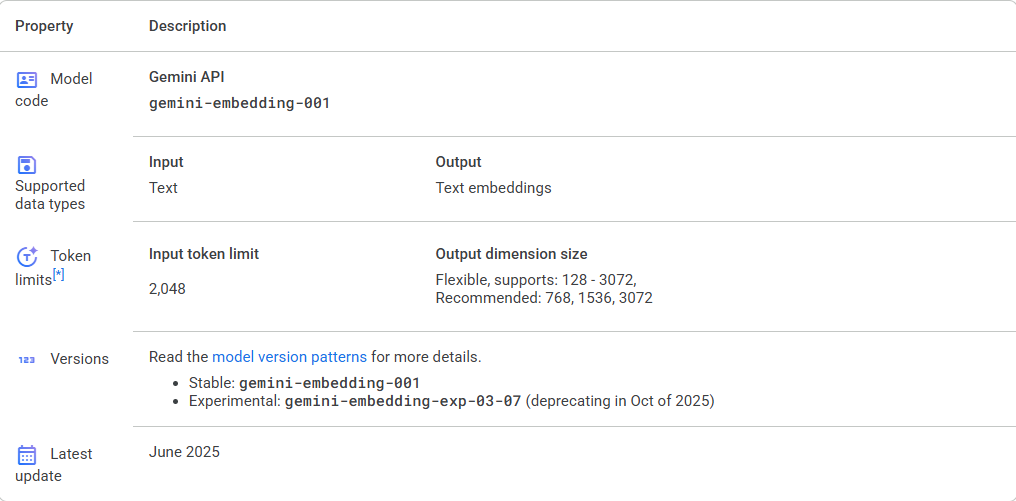

Documentación: https://ai.google.dev/gemini-api/docs/embeddings

In [26]:
#El módulo GoogleGenerativeAIEmbeddings nos permite acceder al modelo de gemini
embedding_model: GoogleGenerativeAIEmbeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")
embedding_vector: list = embedding_model.embed_query("Creando un vector embedding")

#Luego de utilizar el método embed_query podemos obtener un vector de embeddings
embedding_vector[:5]

[0.005278978, -0.009206009, -0.0049079633, -0.08260795, 0.01911122]

In [29]:
#Si tenemos una lista de documentos, podemos calcular los embeddings con el método embedding_model
embedding_vectors_documents: list = embedding_model.embed_documents([chunk.page_content for chunk in textos_split_recursive])

embedding_vectors_documents[:1]

[[-0.0041243783,
  0.0050979536,
  0.020533387,
  -0.066164024,
  0.0070420126,
  0.019037455,
  0.017462062,
  0.0032425502,
  -0.0018436386,
  -0.024120884,
  0.0007870132,
  -0.022540597,
  0.00069040374,
  0.008558528,
  0.1090179,
  0.012713004,
  0.0012427425,
  -0.00943587,
  -0.0069931764,
  -0.009312602,
  0.01312525,
  0.00037324833,
  -0.01619516,
  -0.0005097768,
  0.0040951823,
  0.011410766,
  0.009486331,
  -0.018251663,
  0.012529914,
  0.0018357825,
  -0.0006132949,
  0.0074804793,
  0.0204294,
  -0.0143108135,
  -0.0011556648,
  0.008897148,
  0.0047815703,
  -0.0014945249,
  -0.0066967867,
  0.0115305,
  0.009327241,
  -0.010054424,
  -0.022788728,
  0.024284776,
  0.022502149,
  -0.016959378,
  0.0049944823,
  -0.03499572,
  -0.0026354147,
  0.004300093,
  -0.0024656118,
  -0.0027066444,
  0.011222048,
  -0.23531416,
  -0.02028834,
  0.0065589594,
  -0.007590392,
  -0.0072723893,
  -0.009028475,
  -0.003025411,
  -0.02003937,
  0.03212074,
  -0.021880098,
  -0.00106

### **Vector Stores**

Las bases de datos vectorizadas nos van a permitir almacenar nuestros embeddings y recuperar textos en base a funciones de similitud calculadas sobre los vectores de embeddings.

Para este ejemplo utilizaremos la base de datos vectorizada: ChromaDB

Documentación: https://python.langchain.com/docs/integrations/vectorstores/chroma/

In [30]:
# Se puede inicializar la base de datos de la siguiente manera, si se quiere persistir los datos de chroma se debe utilizar el argumento persist_directory
vector_store: Chroma = Chroma(collection_name="documentos_RAG", embedding_function=embedding_model, persist_directory="./chroma_db")

In [31]:
#Para indexar los documentos en la base de datos vectorizada se debe usar el método from_documents
db_RAG: Chroma = vector_store.from_documents(textos_split_recursive, embedding_model)

In [32]:
#Esta sentencia nos servirá para utilizar nuestra base de datos vectorizada para recuperar secciones de texto relevantes
retriever: VectorStoreRetriever = db_RAG.as_retriever()

### **RAG**

In [36]:

#Inicializamos nuestro modelo chat
model: ChatGoogleGenerativeAI = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

#Creamos nuestra plantilla prompt: Es importante definir una variable donde colocaremos nuestro contexto, el cual será colocado dinámicamente
prompt_text: str = """
Contesta las siguientes preguntas en base al siguiente contexto:

{contexto}

Pregunta: {pregunta}
"""
prompt: ChatPromptValue = ChatPromptTemplate.from_template(prompt_text)

In [37]:
#Creamos nuestra cadena
chain_Rag: RunnableSequence = prompt | model

#Definimos la pregunta
pregunta: str = "¿Cuál fue la organización estatal más extensa e importante de la Sudamérica precolombina?"

#Recuperamos los textos de nuestro documento que sean más similares a nuestra pregunta
docs: list[Document] = retriever.invoke(pregunta)

#Invocamos nuestra cadena para obtener la respuesta - tomemos en cuenta que el contexto ha sido colocado dinámicamente
respuesta: AIMessage = chain_Rag.invoke({"contexto": docs,"pregunta": pregunta})

display(Markdown(respuesta.content))

La organización estatal más extensa e importante de la Sudamérica precolombina fue el **Imperio Inca**.

In [38]:
@chain
def chat_rag(pregunta: str) -> AIMessage:
    """
    Genera una respuesta basada en recuperación aumentada (RAG) para una pregunta dada.

    Esta función implementa un flujo típico de RAG (Retrieval-Augmented Generation):
    1. Recupera los documentos más relevantes en función de la pregunta.
    2. Inserta la información recuperada en un prompt junto con la pregunta.
    3. Invoca el modelo de lenguaje para generar una respuesta contextualizada.

    Args:
        pregunta (str): Pregunta del usuario que se desea responder.

    Returns:
        AIMessage: Respuesta generada por el modelo, enriquecida con el contexto recuperado.
    """
    docs: list[Document] = retriever.invoke(pregunta)

    prompt_con_formato: ChatPromptValue = prompt.invoke({
        "contexto": docs,
        "pregunta": pregunta
    })

    respuesta: AIMessage = model.invoke(prompt_con_formato)

    return respuesta

In [39]:
pregunta: str = "¿Cuál fue la organización estatal más extensa e importante de la Sudamérica precolombina?"

respuesta: AIMessage = chat_rag.invoke(pregunta)

display(Markdown(respuesta.content))

La organización estatal más extensa e importante de la Sudamérica precolombina fue el **Imperio Inca**.